# 01_02 · EDA — CNC Mill Tool Wear

**Dataset:** CNC Mill Tool Wear (Kaggle)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob, os

sns.set_theme(style='whitegrid')
%matplotlib inline

CNC_DIR   = '../data/raw/archive'


## 2. CNC Mill — Carga (train + 18 experimentos)

El dataset CNC está dividido en 18 archivos de experimentos (series temporales de sensores)
más un archivo de metadatos (`train.csv`) que indica si la herramienta estaba desgastada al final.

Lo concatenamos en un único DataFrame para poder hacer el análisis conjunto.


In [2]:
# Metadata de experimentos
train = pd.read_csv(f'{CNC_DIR}/train.csv')
print('train.csv shape:', train.shape)
train


train.csv shape: (18, 7)


,No,material,feedrate,clamp_pressure,tool_condition,machining_finalized,passed_visual_inspection
0,1,wax,6,4.0,unworn,yes,yes
1,2,wax,20,4.0,unworn,yes,yes
2,3,wax,6,3.0,unworn,yes,yes
3,4,wax,6,2.5,unworn,no,NaN
4,5,wax,20,3.0,unworn,no,NaN
5,6,wax,6,4.0,worn,yes,no
6,7,wax,20,4.0,worn,no,NaN
7,8,wax,20,4.0,worn,yes,no
8,9,wax,15,4.0,worn,yes,no
9,10,wax,12,4.0,worn,yes,no


In [3]:
# Cargar y concatenar los 18 archivos de experimento
dfs = []
for i in range(1, 19):
    path = f'{CNC_DIR}/experiment_{i:02d}.csv'
    df = pd.read_csv(path)
    df['experiment'] = i
    dfs.append(df)

cnc_raw = pd.concat(dfs, ignore_index=True)

# Unir con metadata de train.csv
cnc_raw = cnc_raw.merge(train.rename(columns={'No': 'experiment'}), on='experiment', how='left')

print('CNC combinado shape:', cnc_raw.shape)
print('Columnas sensor:', [c for c in cnc_raw.columns if c[0] in 'XYZS' and '1_' in c][:8], '...')
cnc_raw.head(3)


CNC combinado shape: (25286, 55)
Columnas sensor: ['X1_ActualPosition', 'X1_ActualVelocity', 'X1_ActualAcceleration', 'X1_CommandPosition', 'X1_CommandVelocity', 'X1_CommandAcceleration', 'X1_CurrentFeedback', 'X1_DCBusVoltage'] ...


,X1_ActualPosition,X1_ActualVelocity,X1_ActualAcceleration,X1_CommandPosition,X1_CommandVelocity,X1_CommandAcceleration,X1_CurrentFeedback,X1_DCBusVoltage,X1_OutputCurrent,X1_OutputVoltage,...,M1_sequence_number,M1_CURRENT_FEEDRATE,Machining_Process,experiment,material,feedrate,clamp_pressure,tool_condition,machining_finalized,passed_visual_inspection
0,198.0,0.0,0.00,198.0,0.0,0.000000,0.18,0.0207,329.0,2.77,...,0.0,50.0,Starting,1,wax,6,4.0,unworn,yes,yes
1,198.0,-10.8,-350.00,198.0,-13.6,-358.000000,-10.90,0.1860,328.0,23.30,...,4.0,50.0,Prep,1,wax,6,4.0,unworn,yes,yes
2,196.0,-17.8,-6.25,196.0,-17.9,-0.000095,-8.59,0.1400,328.0,30.60,...,7.0,50.0,Prep,1,wax,6,4.0,unworn,yes,yes


## 3. Desbalanceo de clases — CNC

Con **18 experimentos** (10 worn, 8 unworn), el dataset es pequeño pero relativamente balanceado.
El reto principal es el tamaño muestral, no el desbalanceo.


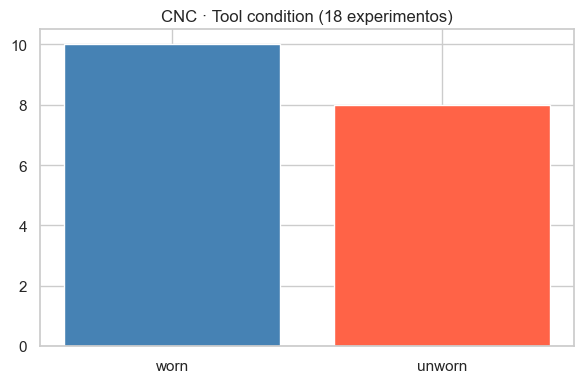

In [4]:
counts2 = train['tool_condition'].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(counts2.index, counts2.values, color=['steelblue', 'tomato'])
plt.title('CNC · Tool condition (18 experimentos)')
plt.tight_layout(); plt.show()


## 6. CNC — Señales de potencia por condición de herramienta

Las señales de potencia del husillo (S1) son las más informativas para distinguir
herramienta desgastada (worn) de nueva (unworn).

Una herramienta desgastada requiere más fuerza para cortar → mayor corriente/potencia.
Si las distribuciones se separan visualmente, esta señal es un buen predictor.


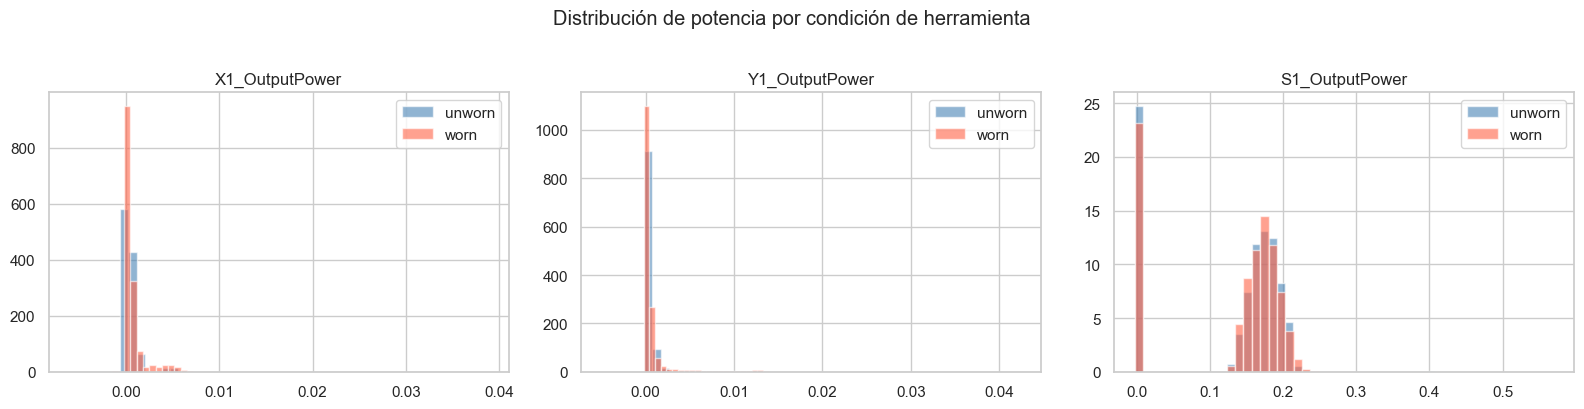

In [5]:
power_cols = ['X1_OutputPower', 'Y1_OutputPower', 'S1_OutputPower']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, power_cols):
    for cond, color in [('unworn', 'steelblue'), ('worn', 'tomato')]:
        subset = cnc_raw[cnc_raw['tool_condition'] == cond][col].dropna()
        subset.hist(ax=ax, bins=50, alpha=0.6, color=color, label=cond, density=True)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Distribución de potencia por condición de herramienta', y=1.02)
plt.tight_layout()
plt.show()


## 7. CNC — Señal temporal de un experimento worn vs unworn

Las series temporales completas de dos experimentos representativos nos muestran
si el desgaste afecta el perfil de la señal a lo largo del tiempo.

Esto nos indica si la **agregación estadística** (media, std, max, min por experimento)
es suficiente o si necesitaríamos features temporales más sofisticadas.


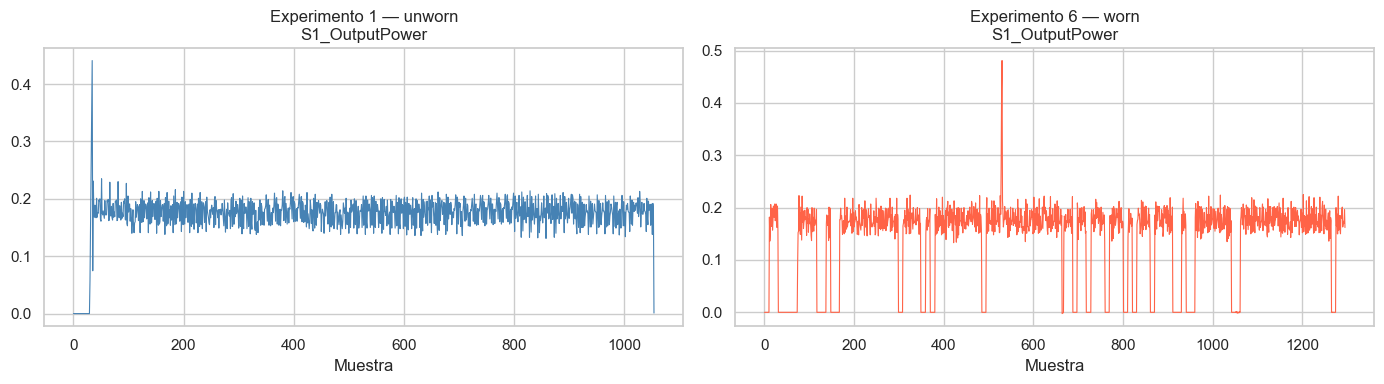

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, exp_id, label, color in [(axes[0], 1, 'unworn', 'steelblue'),
                                   (axes[1], 6, 'worn',   'tomato')]:
    df_exp = cnc_raw[cnc_raw['experiment'] == exp_id]
    ax.plot(df_exp['S1_OutputPower'].values, color=color, linewidth=0.8)
    ax.set_title(f'Experimento {exp_id} — {label}\nS1_OutputPower')
    ax.set_xlabel('Muestra')
plt.tight_layout()
plt.show()


## 7. Conclusiones EDA — CNC Mill

- Las señales de potencia del husillo (S1_OutputPower) separan visualmente worn/unworn
- Con solo 18 muestras, necesitamos LeaveOneOut para evaluar correctamente
- La agregación estadística (media, std) captura el comportamiento medio, no la dinámica

### Implicaciones para 02_02_Preprocesado_CNC
- Agregar series temporales en vectores de features por experimento
- Escalado: necesario para SVM
